In [14]:
# If you need to install packages in this notebook environment, run:
%pip install -q notebook numpy pandas matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

file_path = "Warm_Up_Predict_Blood_Donations_-_Traning_Data.xlsx"  # keep file in same folder
df = pd.read_excel(file_path)

df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [16]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.columns = [
    "Months_since_Last_Donation",
    "Number_of_Donations",
    "Total_Volume_Donated_cc",
    "Months_since_First_Donation",
    "Made_Donation_March_2007"
]

df.head()

,Months_since_Last_Donation,Number_of_Donations,Total_Volume_Donated_cc,Months_since_First_Donation,Made_Donation_March_2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [17]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
df.describe().T

Shape: (576, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Months_since_Last_Donation   576 non-null    int64
 1   Number_of_Donations          576 non-null    int64
 2   Total_Volume_Donated_cc      576 non-null    int64
 3   Months_since_First_Donation  576 non-null    int64
 4   Made_Donation_March_2007     576 non-null    int64
dtypes: int64(5)
memory usage: 22.6 KB

Missing values:
Months_since_Last_Donation     0
Number_of_Donations            0
Total_Volume_Donated_cc        0
Months_since_First_Donation    0
Made_Donation_March_2007       0
dtype: int64

Duplicate rows: 153

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Months_since_Last_Donation,576.0,9.439236,8.175454,0.0,2.0,7.0,14.00,74.0
Number_of_Donations,576.0,5.427083,5.740010,1.0,2.0,4.0,7.00,50.0
Total_Volume_Donated_cc,576.0,1356.770833,1435.002556,250.0,500.0,1000.0,1750.00,12500.0
Months_since_First_Donation,576.0,34.050347,24.227672,2.0,16.0,28.0,49.25,98.0
Made_Donation_March_2007,576.0,0.239583,0.427200,0.0,0.0,0.0,0.00,1.0


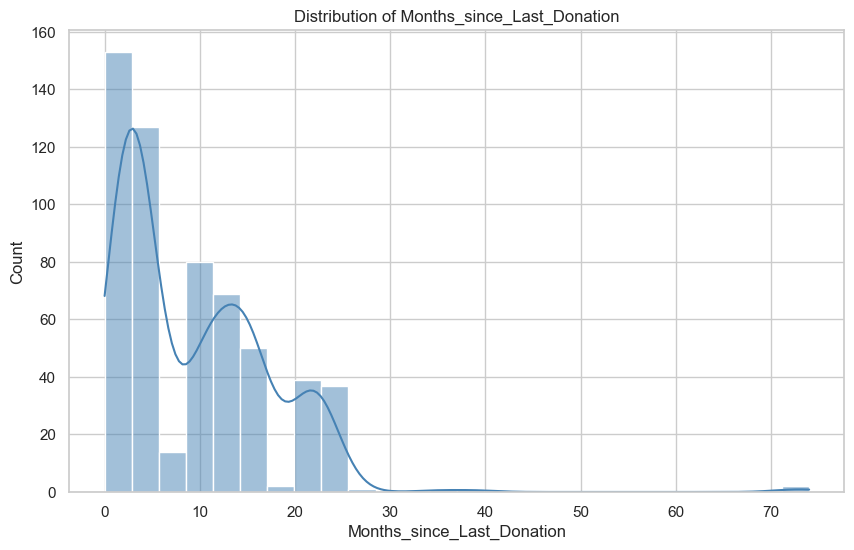

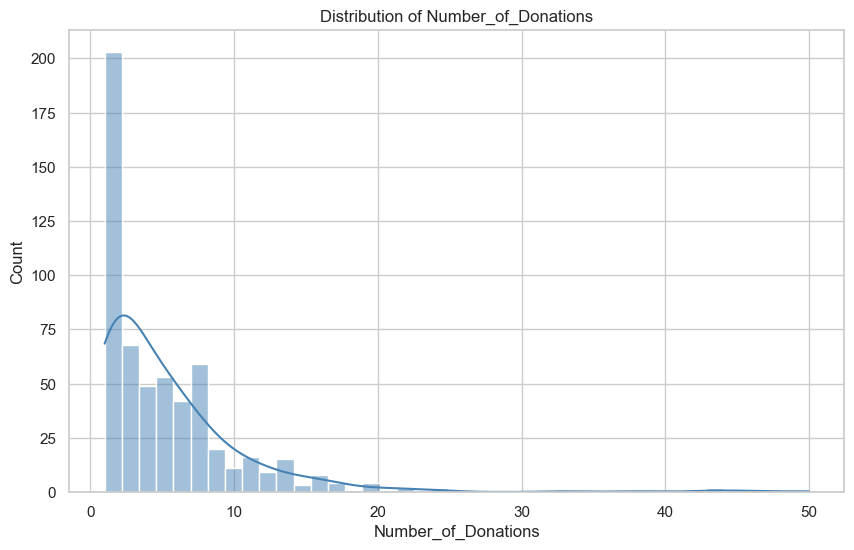

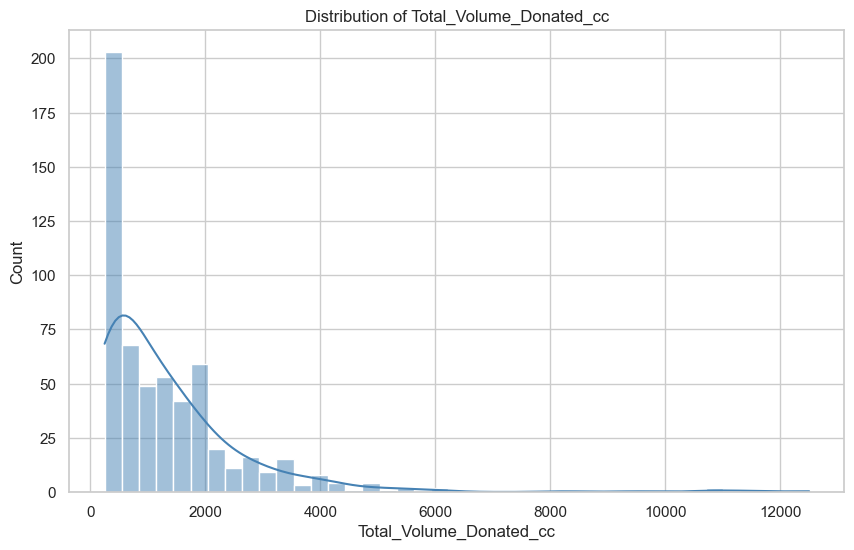

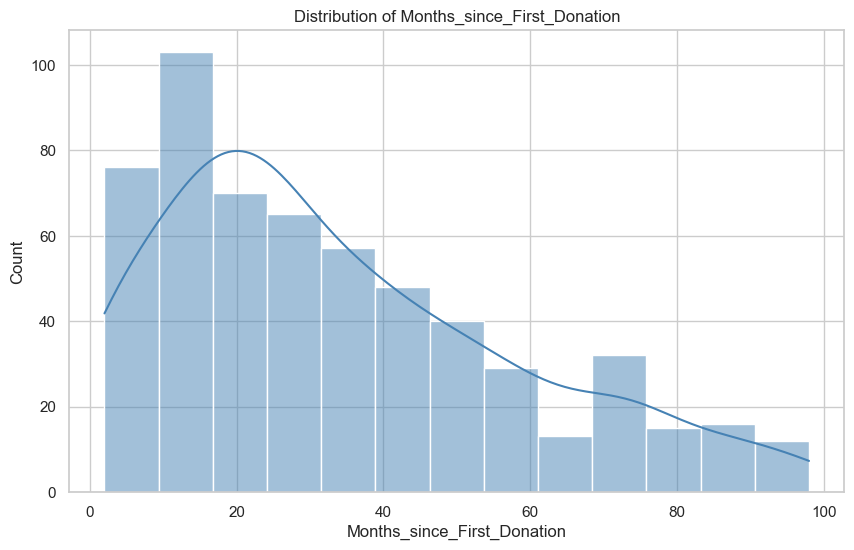

In [18]:
num_cols = [
    "Months_since_Last_Donation",
    "Number_of_Donations",
    "Total_Volume_Donated_cc",
    "Months_since_First_Donation"
]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(f"Distribution of {col}")
    plt.show()
    

Counts:
Made_Donation_March_2007
0    438
1    138
Name: count, dtype: int64

Percentages:
Made_Donation_March_2007
0    76.041667
1    23.958333
Name: proportion, dtype: float64


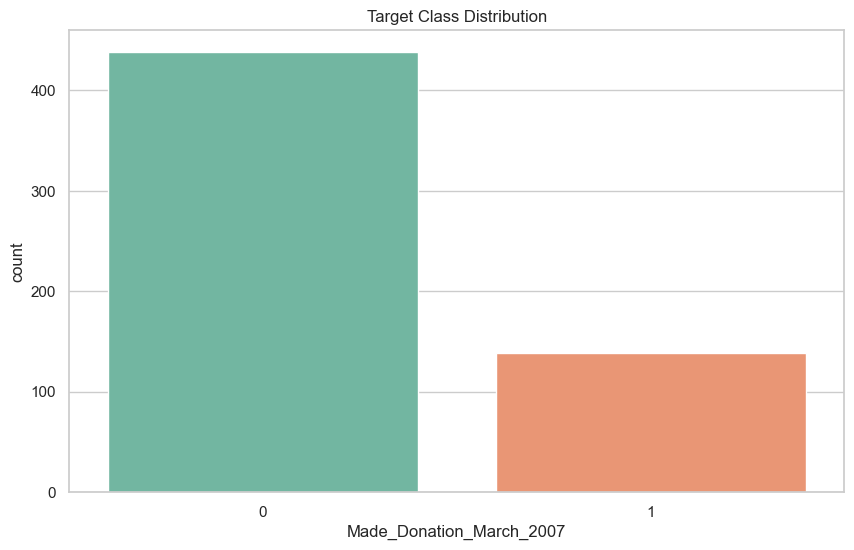

In [19]:
target = "Made_Donation_March_2007"

counts = df[target].value_counts()
perc = df[target].value_counts(normalize=True) * 100

print("Counts:")
print(counts)
print("\nPercentages:")
print(perc)

sns.countplot(x=target, data=df, palette="Set2")
plt.title("Target Class Distribution")
plt.show()

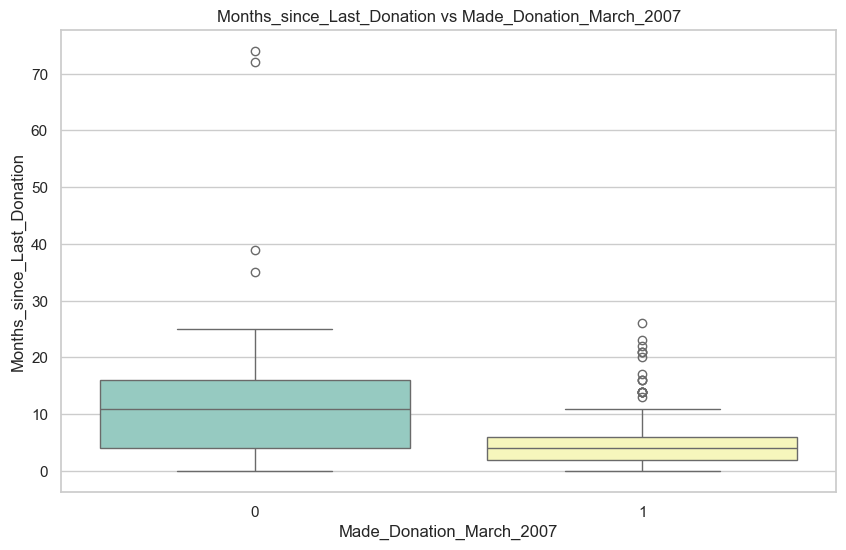

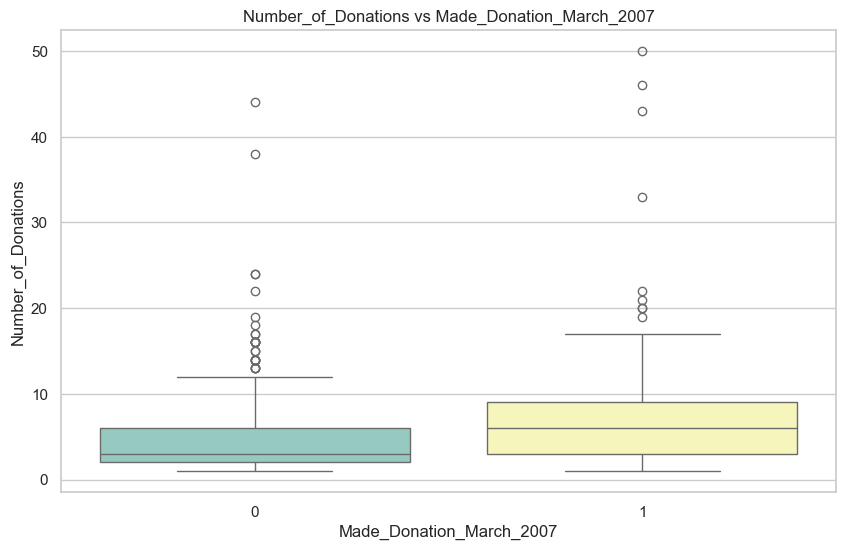

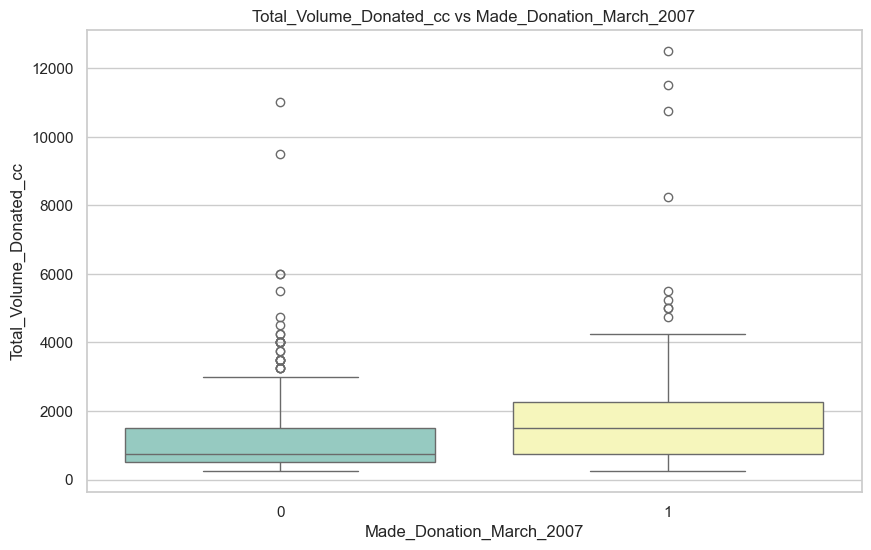

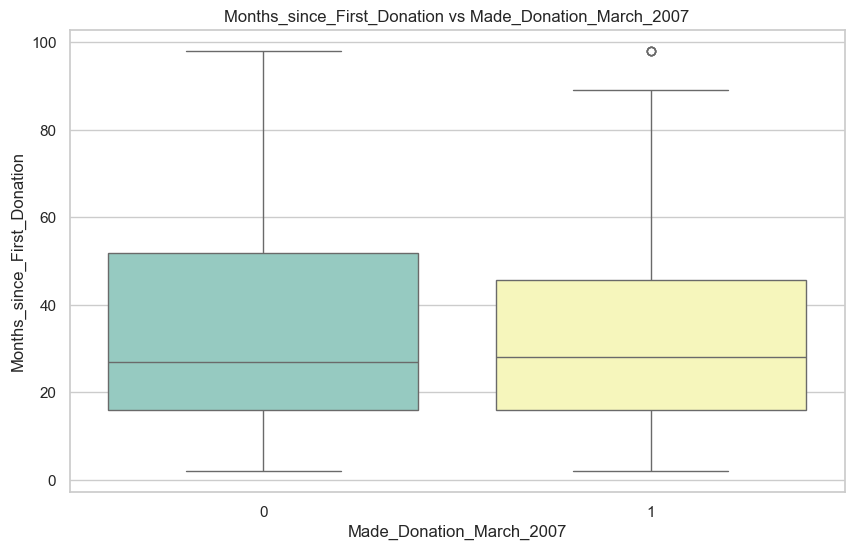

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=target, y=col, data=df, palette="Set3")
    plt.title(f"{col} vs {target}")
    plt.show()

Correlation with target:
Made_Donation_March_2007       1.000000
Number_of_Donations            0.220615
Total_Volume_Donated_cc        0.220615
Months_since_First_Donation   -0.019819
Months_since_Last_Donation    -0.261234
Name: Made_Donation_March_2007, dtype: float64


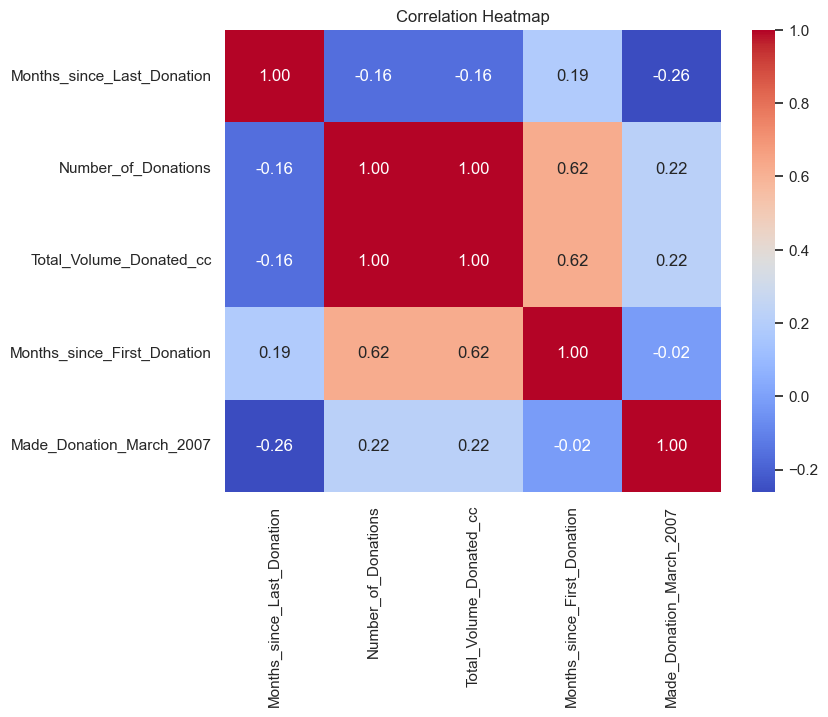

In [21]:
corr = df.corr(numeric_only=True)

print("Correlation with target:")
print(corr[target].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (576, 4)
y shape: (576,)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    y_prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1 Score": f1_score(y, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(["ROC AUC", "F1 Score"], ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.642361,0.376812,0.753623,0.502415,0.746551
4,SVM,0.788194,0.617647,0.304348,0.407767,0.721569
5,KNN,0.774306,0.550000,0.318841,0.403670,0.674947
2,Gradient Boosting,0.763889,0.511628,0.318841,0.392857,0.672201
1,Random Forest,0.723958,0.407080,0.333333,0.366534,0.626166
3,Extra Trees,0.694444,0.356061,0.340580,0.348148,0.587122


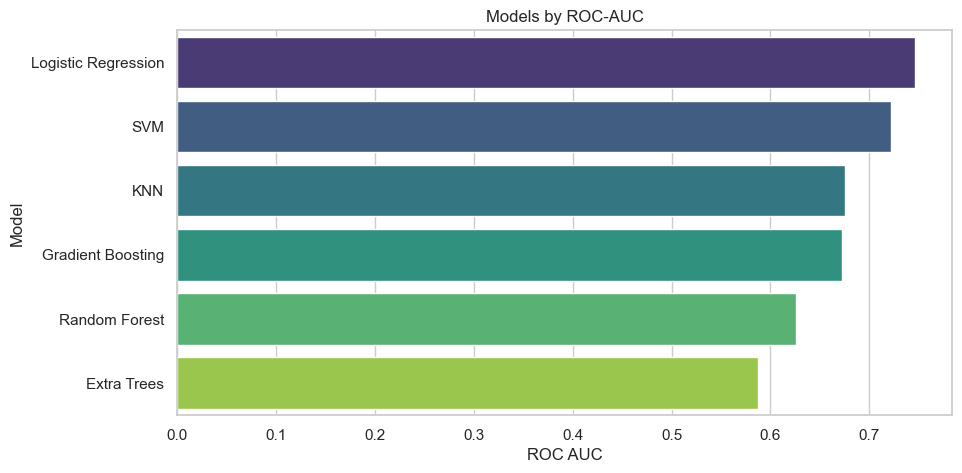

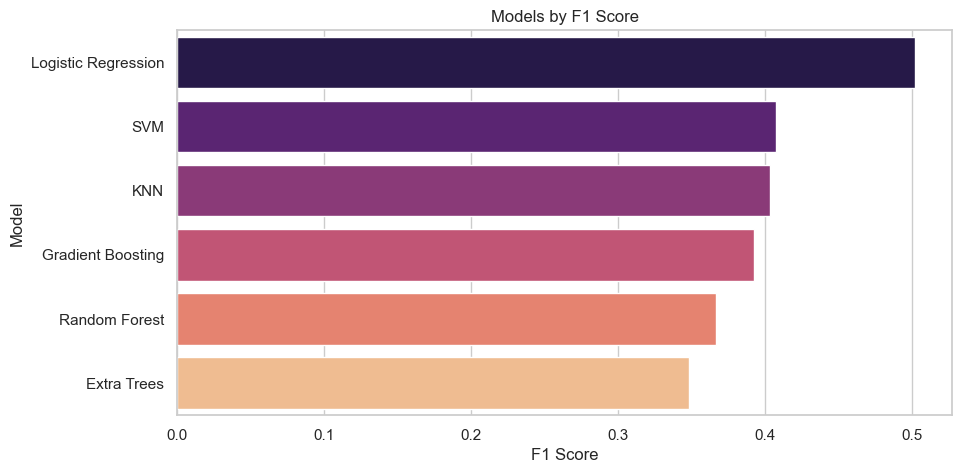

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x="ROC AUC", y="Model", data=results_df, palette="viridis")
plt.title("Models by ROC-AUC")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="F1 Score", y="Model", data=results_df, palette="magma")
plt.title("Models by F1 Score")
plt.show()

Best Model: Logistic Regression

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.61      0.72       438
           1       0.38      0.75      0.50       138

    accuracy                           0.64       576
   macro avg       0.63      0.68      0.61       576
weighted avg       0.76      0.64      0.67       576


Confusion Matrix:
 [[266 172]
 [ 34 104]]


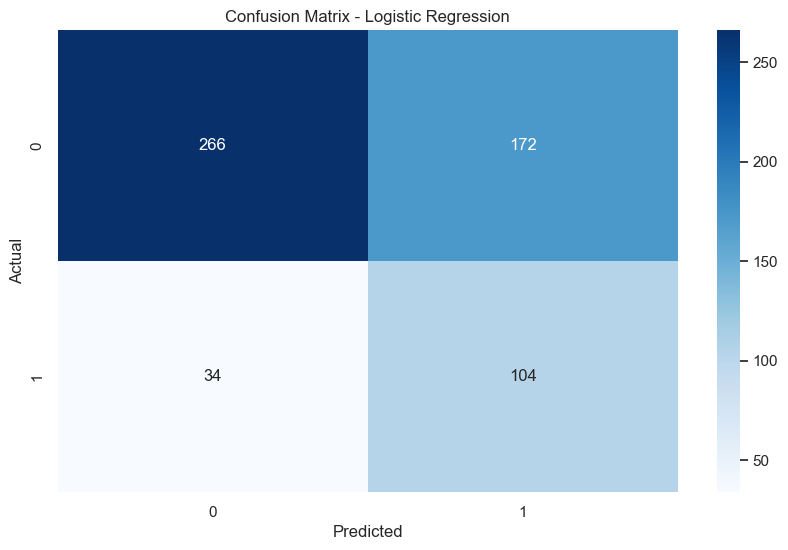

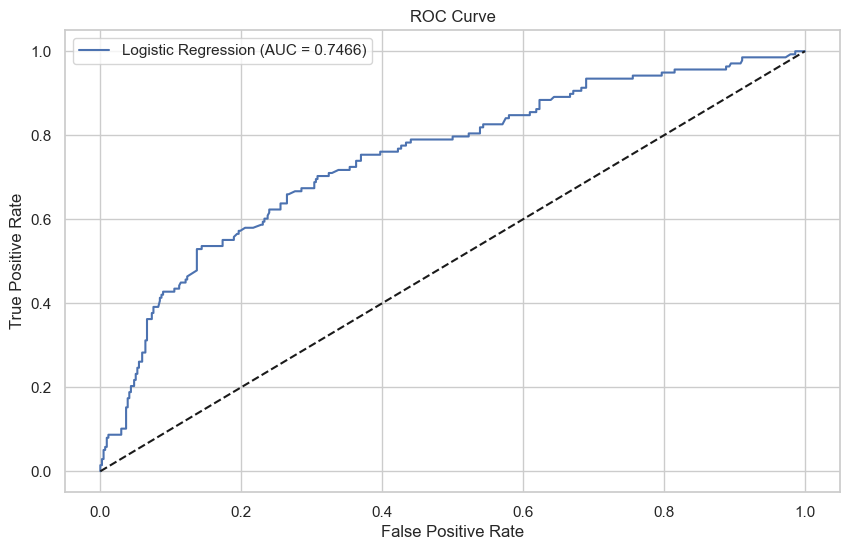

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_pred = predictions[best_model_name]
best_prob = probabilities[best_model_name]

print("\nClassification report:")
print(classification_report(y, best_pred))

cm = confusion_matrix(y, best_pred)
print("\nConfusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y, best_prob)
auc = roc_auc_score(y, best_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X, y)
print(f"Final {best_model_name} model trained on full dataset.")

Final Logistic Regression model trained on full dataset.
